<a href="https://colab.research.google.com/github/HarshiniArulmani2006/Harshini-codeboosters-2026/blob/main/Day_9/Day_9_Agentic_Ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
!pip install groq -q
print("Groq used to call LLMs")
print("Libraries installed successfully!!")

Groq used to call LLMs
Libraries installed successfully!!


In [52]:
import sqlite3
import pandas as pd
import os
from groq import Groq
import re
import io
import matplotlib.pyplot as plt
print("All Libraries imported successfully!!")

All Libraries imported successfully!!


In [53]:
os.environ["GROQ_API_KEY"]="xxxx"
client=Groq(api_key=os.environ["GROQ_API_KEY"])
MODEL="llama-3.1-8b-instant"
print("Groq client initialised sucessfully!!")
print(f"Using Model:{MODEL}")

Groq client initialised sucessfully!!
Using Model:llama-3.1-8b-instant


In [54]:
df=pd.read_csv('student_performance.csv')
print(f"DataSet Loaded:{len(df)} rows,{len(df.columns)} columns")
df.head(5)

DataSet Loaded:30 rows,13 columns


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [55]:
conn=sqlite3.connect("college.db")
df.to_sql("students",conn,if_exists="replace",index=False)  #"students"-->Table name
print("DataBase created:college.db")
print("Table 'students' created with 30 student records")
#verify reading table
test_df=pd.read_sql_query("SELECT COUNT(*) as total_rows FROM students",conn)
print(f"\nVerification:{test_df['total_rows'][0]} rows in database")

DataBase created:college.db
Table 'students' created with 30 student records

Verification:30 rows in database


In [56]:
#Agentic Ai
def get_schema(conn,table_name="students"):
  """
  This is for your reference
  This function reads the structure of database table.
  It returns information about each column
  Returns:
  Formatted string with table schema
  """
  cursor=conn.cursor()
  cursor.execute(f"PRAGMA table_info({table_name})") #returns only column
  columns=cursor.fetchall()
  schema_lines=[f"Table:{table_name}"]
  schema_lines.append("Columns:")
  for col in columns:
    schema_lines.append(f"-->{col[1]}({col[2]})")
  cursor.execute(f"SELECT * FROM {table_name} LIMIT 3")
  sample_rows=cursor.fetchall()
  schema_lines.append("\nSample rows(first 3):")
  for row in sample_rows:
    schema_lines.append(f"{row}")
    return "\n".join(schema_lines)
schema=get_schema(conn)
print(schema)

Table:students
Columns:
-->student_id(INTEGER)
-->name(TEXT)
-->age(INTEGER)
-->gender(TEXT)
-->department(TEXT)
-->semester(INTEGER)
-->math_score(INTEGER)
-->science_score(INTEGER)
-->english_score(INTEGER)
-->programming_score(INTEGER)
-->attendance_percentage(INTEGER)
-->city(TEXT)
-->admission_year(INTEGER)

Sample rows(first 3):
(1001, 'Aarav Sharma', 19, 'Male', 'Computer Science', 2, 85, 78, 72, 91, 92, 'Mumbai', 2023)


In [57]:
#generate
def generate_sql(user_question,schema_text,client,model):
  """
  This is the reference for you
  Sends the user's question and database schema to the groq
  The LLm generates SQL query
  Returns:
  SQL query as a string
  """
  system_prompt=f"""You are an expert SQL assistant.
  You are connected to a SQLite database with the following structure
  {schema_text}
  Rules you must follow:
  1. Generate ONLY a valid SQLite SQL query.
  2. Do not include any explanation or text — only the SQL query.
  3. Do not use markdown code blocks. Return the raw SQL only.
  4. The table name is: students
  5. Only use column names that exist in the schema above.
  6. Use single quotes for string values in WHERE clauses (example: WHERE subject = 'Programming').
  7. If the user asks for top N, use ORDER BY marks DESC LIMIT N.
  """
  response=client.chat.completions.create(
      model=model,
      messages=[
          {"role":"system","content":system_prompt},
          {"role":"user","content":user_question}
      ],
      temperature=0.0
  )
  sql_query=response.choices[0].message.content.strip()
  return sql_query
question="Show me all Female Students"
print(f"Quetion:{question}")
print(f"\nGenerating SQL Query....")
sql=generate_sql(question,schema,client,MODEL)
print(f"\nGenerated SQL Query:\n{sql}")

Quetion:Show me all Female Students

Generating SQL Query....

Generated SQL Query:
SELECT * FROM students WHERE gender = 'Female'


In [58]:
#generate
def generate_sql(user_question,schema_text,client,model):
  """
  This is the reference for you
  Sends the user's question and database schema to the groq
  The LLm generates SQL query
  Returns:
  SQL query as a string
  """
  system_prompt=f"""You are an expert SQL assistant.
  You are connected to a SQLite database with the following structure
  {schema_text}
  Rules you must follow:
  1. Generate ONLY a valid SQLite SQL query.
  2. Do not include any explanation or text — only the SQL query.
  3. Do not use markdown code blocks. Return the raw SQL only.
  4. The table name is: students
  5. Only use column names that exist in the schema above.
  6. Use single quotes for string values in WHERE clauses (example: WHERE subject = 'Programming').
  7. If the user asks for top N, use ORDER BY marks DESC LIMIT N.
  """
  response=client.chat.completions.create(
      model=model,
      messages=[
          {"role":"system","content":system_prompt},
          {"role":"user","content":user_question}
      ],
      temperature=0.0
  )
  sql_query=response.choices[0].message.content.strip()
  return sql_query
question="Show me all Female Students who scored above 80% in programming_score"
print(f"Quetion:{question}")
print(f"\nGenerating SQL Query....")
sql=generate_sql(question,schema,client,MODEL)
print(f"\nGenerated SQL Query:\n{sql}")

Quetion:Show me all Female Students who scored above 80% in programming_score

Generating SQL Query....

Generated SQL Query:
SELECT * FROM students WHERE gender = 'Female' AND programming_score > 80


In [59]:
#execute
def execute_sql(sql_query,conn):
  """
  This is for your reference
  Cleans the AI generated SQL and executes it on the SQLite database
  Returns results as a pandas as a Panda dataframe
  Returns:
  A pandas dataframe with query results
  """
  clean_sql=sql_query.strip()  #strip()--removes white space
  clean_sql=re.sub(r'```sql\s*','',clean_sql)
  clean_sql=clean_sql.strip()
  try:
    result_df=pd.read_sql_query(clean_sql,conn)
    return result_df,None
  except Exception as e:
    return None,str(e)
print(f"Exception SQL:{sql}")
result,error=execute_sql(sql,conn)
if error:
  print(f"Error:{error}")
else:
  print(f"\nQuery retruned {len(result)} rows:")
  print(result)

Exception SQL:SELECT * FROM students WHERE gender = 'Female' AND programming_score > 80

Query retruned 6 rows:
   student_id            name  age  gender        department  semester  \
0        1008     Divya Singh   19  Female  Computer Science         2   
1        1010      Ananya Das   19  Female  Computer Science         2   
2        1018  Swati Kulkarni   19  Female  Computer Science         2   
3        1020    Nisha Kapoor   19  Female  Computer Science         2   
4        1022     Tanvi Mehta   19  Female  Computer Science         2   
5        1030  Akanksha Yadav   19  Female  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          88             91             84                 93   
1          95             89             90                 97   
2          90             87             85                 92   
3          79             84             81                 83   
4          93             90           

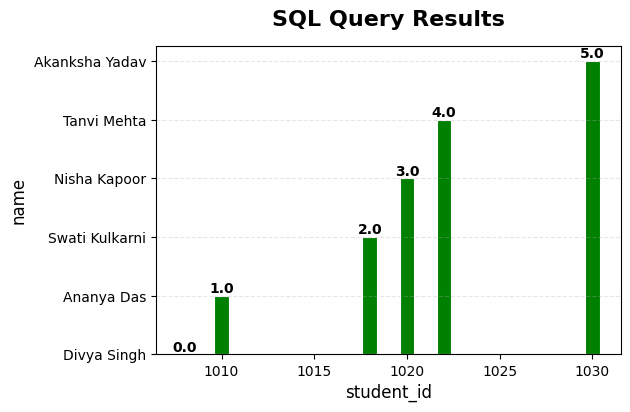

In [60]:
  fig,ax=plt.subplots(figsize=(6,4))
  bars=ax.bar(
      result.iloc[:,0],
      result.iloc[:,1],
      color='#008000',
      edgecolor='white',
      linewidth=0.8
  )
  for bar in bars:
      height=bar.get_height()
      ax.text(
          bar.get_x()+bar.get_width()/2,
          height,
          f"{height:.1f}",
          ha='center',
          va='bottom',
          fontsize=10,
          fontweight='bold',
          color='black'
      )
  ax.set_title(
      "SQL Query Results",
      fontsize=16,
      fontweight='bold',
      pad=15
  )
  ax.set_xlabel(result.columns[0], fontsize=12)
  ax.set_ylabel(result.columns[1], fontsize=12)
  ax.grid(axis='y', alpha=0.3, linestyle='--')
  plt.show()

In [61]:
def text_to_sql_agent(user_question,conn,client,model,verbose=True):
  """
  The main AI Agent function.
  Takes a user question in plain english and returns database results

  This is the complete work flow:
  1.Get database schema
  2.Ggenerate SQL using Groa LLM
  3.Execute SQL on database
  4.Format and return results
  Returns:
    SQL Query
  """
  print(f"USER QUESTION:{user_question}")
  if verbose:
    print("\nReading database schema...")
  schema_text=get_schema(conn)
  if verbose:
    print("Schema loaded successfully!!")
  if verbose:
    print("\nGenerating SQL Query with Groq LLM....")
  generated_sql=generate_sql(user_question,schema_text,client,model)
  if verbose:
    print(f"Generated SQL:\n{generated_sql}")
  if verbose:
    print("\nExecuting SQL on the database....")
  result_df,error=execute_sql(generated_sql,conn)
  if error:
    print(f"SQL Execution Error:{error}")
    return None,generated_sql
  if verbose:
    print(f"\nQuery returned {len(result_df)} rows")
    print("\nRESLUTS:")
    print(result_df.to_string(index=False))
  return result_df,generated_sql
result,sql_used=text_to_sql_agent(
    "Show the top 5 students who has above 80% of attendance",
    conn,client,MODEL
)

USER QUESTION:Show the top 5 students who has above 80% of attendance

Reading database schema...
Schema loaded successfully!!

Generating SQL Query with Groq LLM....
Generated SQL:
SELECT name, attendance_percentage FROM students WHERE attendance_percentage > 80 ORDER BY attendance_percentage DESC LIMIT 5

Executing SQL on the database....

Query returned 5 rows

RESLUTS:
          name  attendance_percentage
    Ananya Das                     98
   Tanvi Mehta                     97
   Divya Singh                     96
   Sneha Reddy                     95
Akanksha Yadav                     95


In [63]:
def text_to_sql_agent(user_question,conn,client,model,verbose=True):
  """
  The main AI Agent function.
  Takes a user question in plain english and returns database results

  This is the complete work flow:
  1.Get database schema
  2.Ggenerate SQL using Groa LLM
  3.Execute SQL on database
  4.Format and return results
  Returns:
    SQL Query
  """
  print(f"USER QUESTION:{user_question}")
  if verbose:
    print("\nReading database schema...")
  schema_text=get_schema(conn)
  if verbose:
    print("Schema loaded successfully!!")
  if verbose:
    print("\nGenerating SQL Query with Groq LLM....")
  generated_sql=generate_sql(user_question,schema_text,client,model)
  if verbose:
    print(f"Generated SQL:\n{generated_sql}")
  if verbose:
    print("\nExecuting SQL on the database....")
  result_df,error=execute_sql(generated_sql,conn)
  if error:
    print(f"SQL Execution Error:{error}")
    return None,generated_sql
  if verbose:
    print(f"\nQuery returned {len(result_df)} rows")
    print("\nRESLUTS:")
    print(result_df.to_string(index=False))
  return result_df,generated_sql
result,sql_used=text_to_sql_agent(
    "Show the top 5 students in programming with score",
    conn,client,MODEL
)

USER QUESTION:Show the top 5 students in programming with score

Reading database schema...
Schema loaded successfully!!

Generating SQL Query with Groq LLM....
Generated SQL:
SELECT name, programming_score FROM students ORDER BY programming_score DESC LIMIT 5

Executing SQL on the database....

Query returned 5 rows

RESLUTS:
          name  programming_score
    Ananya Das                 97
   Tanvi Mehta                 96
    Arjun Nair                 95
Akanksha Yadav                 94
   Divya Singh                 93
